# Practical Feature Engineering for Classification

## Project Overview

This project uses feature engineering for a binary classification problem. The goal is to predict whether a breast tumor is malignant or benign using diagnostic measurements from cell nuclei.

The project covers two major parts of feature engineering:

1. Feature selection  
2. Feature extraction  

Feature selection keeps a subset of the original variables, while feature extraction creates new transformed variables from the original data.

## Methods Covered

### Feature Selection

- Recursive Feature Elimination - removes less important features recursively
- Sequential Feature Selection
- Mutual Information
- Chi-Square
- Correlation-based selection
- Decision Tree-based feature importance

### Feature Extraction

- Principal Component Analysis
- Linear Discriminant Analysis
- Kernel PCA
- Quadratic Discriminant Analysis

## Important Note

Quadratic Discriminant Analysis is not technically a feature extraction method. It is a classification model. It is included here because it is closely related to Linear Discriminant Analysis, but unlike LDA, QDA does not provide a direct feature transformation in scikit-learn.

### Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    RFE,
    SequentialFeatureSelector,
    SelectKBest,
    mutual_info_classif,
    chi2
)

from sklearn.decomposition import PCA, KernelPCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

### Load the dataset

In [5]:
df = pd.read_csv("breast_cancer_classification.csv")

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         569 non-null

In [7]:
df["diagnosis_label"].value_counts()

diagnosis_label
benign       357
malignant    212
Name: count, dtype: int64

For a medical classification problem, it is useful to define malignant as the positive class.

In [11]:
X = df.drop(columns=["diagnosis", "diagnosis_label"])

y = np.where(df["diagnosis_label"] == "malignant", 1, 0)

y = pd.Series(y, name="malignant")

In [12]:
# The new target
y.value_counts()

malignant
0    357
1    212
Name: count, dtype: int64

In [13]:
y.value_counts(normalize=True)

malignant
0    0.627417
1    0.372583
Name: proportion, dtype: float64

### Train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)

Training shape: (455, 30)
Test shape: (114, 30)


### Evaluation function

In [15]:
def evaluate_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC AUC": roc_auc_score(y_test, y_proba)
    }
    
    return results

### Baseline model with all features

In [16]:
baseline_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

baseline_model.fit(X_train, y_train)

baseline_results = evaluate_model(
    "Baseline Logistic Regression",
    baseline_model,
    X_test,
    y_test
)

baseline_results

{'Model': 'Baseline Logistic Regression',
 'Accuracy': 0.9649122807017544,
 'Precision': np.float64(0.975),
 'Recall': np.float64(0.9285714285714286),
 'F1 Score': np.float64(0.9512195121951219),
 'ROC AUC': np.float64(0.996031746031746)}

The baseline model uses all original features. This gives us a reference point for comparing whether feature selection or feature extraction improves performance.

## Part A: Feature Selection

## Wrapper method

### Wrapper method 1: Recursive Feature Elimination

In [17]:
# select 10 features
rfe_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("selector", RFE(
            estimator=LogisticRegression(max_iter=1000, random_state=42),
            n_features_to_select=10
        )),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

rfe_model.fit(X_train, y_train)

rfe_results = evaluate_model(
    "RFE Logistic Regression",
    rfe_model,
    X_test,
    y_test
)

rfe_results

{'Model': 'RFE Logistic Regression',
 'Accuracy': 0.9736842105263158,
 'Precision': np.float64(0.975609756097561),
 'Recall': np.float64(0.9523809523809523),
 'F1 Score': np.float64(0.963855421686747),
 'ROC AUC': np.float64(0.9973544973544973)}

In [18]:
results = pd.DataFrame([
    baseline_results,
    rfe_results
])

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Baseline Logistic Regression,0.964912,0.97500,0.928571,0.951220,0.996032
1,RFE Logistic Regression,0.973684,0.97561,0.952381,0.963855,0.997354


RFE Logistic Regression is preferred because it improves accuracy, recall, F1 score, and ROC AUC while using a smaller set of selected features.

In [19]:
# Get selected features
rfe_selector = rfe_model.named_steps["selector"]

rfe_features = X_train.columns[rfe_selector.support_]

rfe_features

Index(['mean concave points', 'radius error', 'area error',
       'compactness error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst concavity', 'worst concave points'],
      dtype='str')

### Wrapper method 2: Sequential Feature Selection

Sequential Feature Selection adds or removes features step by step based on model performance.

In [20]:
sfs_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("selector", SequentialFeatureSelector(
            estimator=LogisticRegression(max_iter=1000, random_state=42),
            n_features_to_select=10,
            direction="forward",
            scoring="roc_auc",
            cv=5,
            n_jobs=-1
        )),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

sfs_model.fit(X_train, y_train)

sfs_results = evaluate_model(
    "Sequential Feature Selection",
    sfs_model,
    X_test,
    y_test
)

sfs_results

{'Model': 'Sequential Feature Selection',
 'Accuracy': 0.956140350877193,
 'Precision': np.float64(0.9743589743589743),
 'Recall': np.float64(0.9047619047619048),
 'F1 Score': np.float64(0.9382716049382716),
 'ROC AUC': np.float64(0.9976851851851851)}

In [21]:
# Get selected features
sfs_selector = sfs_model.named_steps["selector"]

sfs_features = X_train.columns[sfs_selector.get_support()]

sfs_features

Index(['radius error', 'texture error', 'area error', 'compactness error',
       'concave points error', 'worst texture', 'worst perimeter',
       'worst smoothness', 'worst concavity', 'worst concave points'],
      dtype='str')

## Filtering methods

Filter methods select features using statistical scores. They are usually faster than wrapper methods.

### Filter method 1: Mutual Information

In [22]:
mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=10
)

mi_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("selector", mi_selector),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

mi_model.fit(X_train, y_train)

mi_results = evaluate_model(
    "Mutual Information Selection",
    mi_model,
    X_test,
    y_test
)

mi_results

{'Model': 'Mutual Information Selection',
 'Accuracy': 0.9649122807017544,
 'Precision': np.float64(0.975),
 'Recall': np.float64(0.9285714285714286),
 'F1 Score': np.float64(0.9512195121951219),
 'ROC AUC': np.float64(0.9976851851851851)}

In [23]:
# Get Mutual Information scores
mi_scores = mi_model.named_steps["selector"].scores_

mi_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Mutual Information Score": mi_scores
}).sort_values(
    by="Mutual Information Score",
    ascending=False
)

mi_table.head(10)

,Feature,Mutual Information Score
20,worst radius,0.459483
23,worst area,0.452610
22,worst perimeter,0.452166
7,mean concave points,0.448032
27,worst concave points,0.431347
2,mean perimeter,0.409228
3,mean area,0.374048
0,mean radius,0.372564
6,mean concavity,0.354031
13,area error,0.348824


### Filter method 2: Chi-Square

The chi-square method measures the association between each feature and the target variable. Since chi-square requires nonnegative values, MinMax scaling is used before feature selection.

In [24]:
chi2_model = Pipeline(
    steps=[
        ("scaler", MinMaxScaler()),
        ("selector", SelectKBest(score_func=chi2, k=10)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

chi2_model.fit(X_train, y_train)

chi2_results = evaluate_model(
    "Chi Square Selection",
    chi2_model,
    X_test,
    y_test
)

chi2_results

{'Model': 'Chi Square Selection',
 'Accuracy': 0.9385964912280702,
 'Precision': np.float64(0.972972972972973),
 'Recall': np.float64(0.8571428571428571),
 'F1 Score': np.float64(0.9113924050632911),
 'ROC AUC': np.float64(0.9953703703703703)}

In [25]:
# Get Chi Square scores
chi2_scores = chi2_model.named_steps["selector"].scores_

chi2_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Chi Square Score": chi2_scores
}).sort_values(
    by="Chi Square Score",
    ascending=False
)

chi2_table.head(10)

,Feature,Chi Square Score
7,mean concave points,43.632020
27,worst concave points,37.318311
6,mean concavity,37.211946
23,worst area,28.725948
22,worst perimeter,28.174364
20,worst radius,27.854482
26,worst concavity,24.511964
3,mean area,24.016887
2,mean perimeter,21.675552
0,mean radius,20.311507


### Filter method 3: Correlation with target

Correlation based selection keeps features most strongly related to the target.

In [26]:
correlation_table = X_train.copy()
correlation_table["target"] = y_train.values

correlations = correlation_table.corr(numeric_only=True)["target"].drop("target")

correlation_scores = correlations.abs().sort_values(ascending=False)

top_corr_features = correlation_scores.head(10).index.tolist()

top_corr_features

['worst concave points',
 'worst perimeter',
 'worst radius',
 'mean concave points',
 'mean perimeter',
 'worst area',
 'mean radius',
 'mean area',
 'mean concavity',
 'worst concavity']

In [27]:
# Train a model using only the top correlation features
corr_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

corr_model.fit(X_train[top_corr_features], y_train)

corr_results = evaluate_model(
    "Correlation Selection",
    corr_model,
    X_test[top_corr_features],
    y_test
)

corr_results

{'Model': 'Correlation Selection',
 'Accuracy': 0.956140350877193,
 'Precision': np.float64(0.9743589743589743),
 'Recall': np.float64(0.9047619047619048),
 'F1 Score': np.float64(0.9382716049382716),
 'ROC AUC': np.float64(0.9973544973544974)}

#### Plot the top correlated features

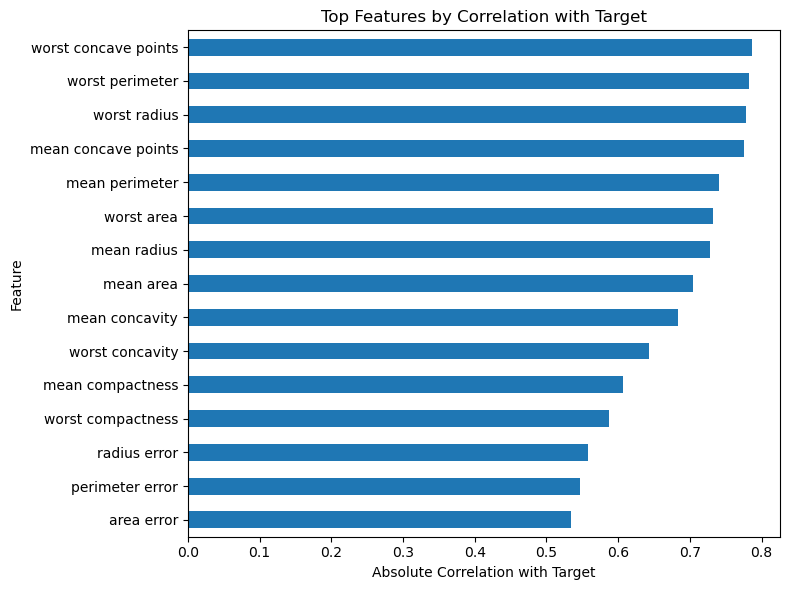

In [28]:
plt.figure(figsize=(8, 6))

correlation_scores.head(15).sort_values().plot(kind="barh")

plt.xlabel("Absolute Correlation with Target")
plt.ylabel("Feature")
plt.title("Top Features by Correlation with Target")
plt.tight_layout()
plt.show()

## Embedded methods

Embedded methods perform feature selection during model training.

### Embedded method: Decision Tree feature importance

Decision Trees provide embedded feature importance because feature selection happens as the tree is trained. Features that create stronger splits receive higher importance scores.

In [30]:
tree_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

tree_importance.head(10)

,Feature,Importance
22,worst perimeter,0.761165
27,worst concave points,0.071259
1,mean texture,0.030683
24,worst smoothness,0.026109
3,mean area,0.023632
21,worst texture,0.023064
23,worst area,0.023017
26,worst concavity,0.017348
13,area error,0.011862
11,texture error,0.011862


In [31]:
# Select the top 10 tree based features
top_tree_features = tree_importance.head(10)["Feature"].tolist()
top_tree_features

['worst perimeter',
 'worst concave points',
 'mean texture',
 'worst smoothness',
 'mean area',
 'worst texture',
 'worst area',
 'worst concavity',
 'area error',
 'texture error']

In [32]:
tree_selected_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

tree_selected_model.fit(X_train[top_tree_features], y_train)

tree_selected_results = evaluate_model(
    "Decision Tree Feature Importance",
    tree_selected_model,
    X_test[top_tree_features],
    y_test
)

tree_selected_results

{'Model': 'Decision Tree Feature Importance',
 'Accuracy': 0.9649122807017544,
 'Precision': np.float64(0.975),
 'Recall': np.float64(0.9285714285714286),
 'F1 Score': np.float64(0.9512195121951219),
 'ROC AUC': np.float64(0.998015873015873)}

#### Plot Decision Tree importance

<Figure size 800x600 with 0 Axes>

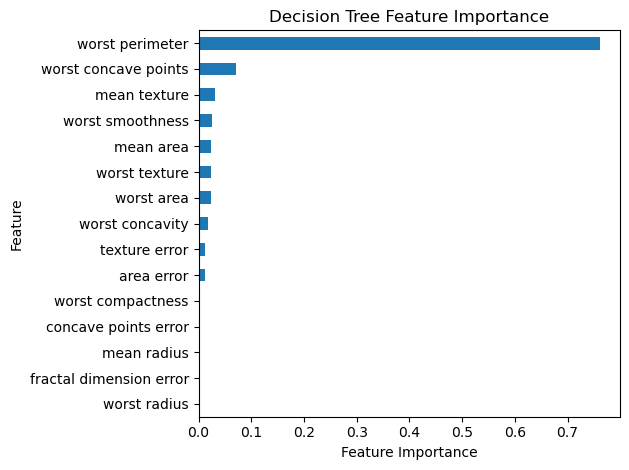

In [33]:
plt.figure(figsize=(8, 6))

tree_importance.head(15).sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.show()

## Part B: Feature Extraction

Feature extraction creates new features from the original variables.

### Principal Component Analysis
PCA is useful when many features are correlated. It reduces dimensionality by creating new components that summarize the original features. The main weakness is that the new components are less interpretable than the original variables.

In [34]:
pca_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=5, random_state=42)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

pca_model.fit(X_train, y_train)

pca_results = evaluate_model(
    "PCA Logistic Regression",
    pca_model,
    X_test,
    y_test
)

pca_results

{'Model': 'PCA Logistic Regression',
 'Accuracy': 0.9736842105263158,
 'Precision': np.float64(0.975609756097561),
 'Recall': np.float64(0.9523809523809523),
 'F1 Score': np.float64(0.963855421686747),
 'ROC AUC': np.float64(0.9963624338624338)}

In [35]:
# Check explained variance
pca_step = pca_model.named_steps["pca"]

explained_variance = pd.DataFrame({
    "Component": [f"PC{i+1}" for i in range(pca_step.n_components_)],
    "Explained Variance Ratio": pca_step.explained_variance_ratio_,
    "Cumulative Explained Variance": np.cumsum(pca_step.explained_variance_ratio_)
})

explained_variance

,Component,Explained Variance Ratio,Cumulative Explained Variance
0,PC1,0.445935,0.445935
1,PC2,0.185453,0.631388
2,PC3,0.095846,0.727234
3,PC4,0.065938,0.793172
4,PC5,0.056223,0.849395


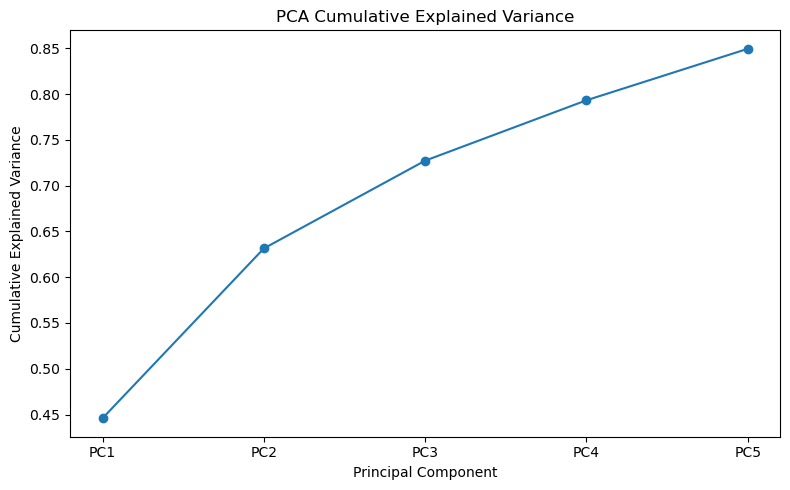

In [36]:
# Plot explained variance
plt.figure(figsize=(8, 5))

plt.plot(
    explained_variance["Component"],
    explained_variance["Cumulative Explained Variance"],
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.tight_layout()
plt.show()

### Linear Discriminant Analysis

LDA is a supervised feature extraction method. Unlike PCA, which only looks at feature variance, LDA uses the target labels and tries to create components that separate the classes as much as possible. For binary classification, LDA can create at most one component.

In [37]:
lda_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("lda", LinearDiscriminantAnalysis(n_components=1)),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

lda_model.fit(X_train, y_train)

lda_results = evaluate_model(
    "LDA Feature Extraction",
    lda_model,
    X_test,
    y_test
)

lda_results

{'Model': 'LDA Feature Extraction',
 'Accuracy': 0.9736842105263158,
 'Precision': np.float64(0.975609756097561),
 'Recall': np.float64(0.9523809523809523),
 'F1 Score': np.float64(0.963855421686747),
 'ROC AUC': np.float64(0.9970238095238095)}

### Kernel PCA

Kernel PCA is a nonlinear extension of PCA. It can capture nonlinear structure in the data.

Kernel PCA can improve performance when linear PCA is too restrictive, but it is less interpretable and requires tuning.

In [38]:
kernel_pca_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("kernel_pca", KernelPCA(
            n_components=5,
            kernel="rbf",
            gamma=0.05,
            random_state=42
        )),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

kernel_pca_model.fit(X_train, y_train)

kernel_pca_results = evaluate_model(
    "Kernel PCA Logistic Regression",
    kernel_pca_model,
    X_test,
    y_test
)

kernel_pca_results

{'Model': 'Kernel PCA Logistic Regression',
 'Accuracy': 0.9210526315789473,
 'Precision': np.float64(0.8837209302325582),
 'Recall': np.float64(0.9047619047619048),
 'F1 Score': np.float64(0.8941176470588236),
 'ROC AUC': np.float64(0.986441798941799)}

### Quadratic Discriminant Analysis

QDA is a classifier, not a direct feature extraction method. It allows each class to have its own covariance structure, which creates nonlinear decision boundaries.

In [39]:
qda_model = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("model", QuadraticDiscriminantAnalysis(reg_param=0.1))
    ]
)

qda_model.fit(X_train, y_train)

qda_results = evaluate_model(
    "Quadratic Discriminant Analysis",
    qda_model,
    X_test,
    y_test
)

qda_results

{'Model': 'Quadratic Discriminant Analysis',
 'Accuracy': 0.9385964912280702,
 'Precision': np.float64(0.972972972972973),
 'Recall': np.float64(0.8571428571428571),
 'F1 Score': np.float64(0.9113924050632911),
 'ROC AUC': np.float64(0.996031746031746)}

### Compare all methods

In [40]:
all_results = pd.DataFrame([
    baseline_results,
    rfe_results,
    sfs_results,
    mi_results,
    chi2_results,
    corr_results,
    tree_selected_results,
    pca_results,
    lda_results,
    kernel_pca_results,
    qda_results
])

all_results.sort_values(by="ROC AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
6,Decision Tree Feature Importance,0.964912,0.975000,0.928571,0.951220,0.998016
2,Sequential Feature Selection,0.956140,0.974359,0.904762,0.938272,0.997685
3,Mutual Information Selection,0.964912,0.975000,0.928571,0.951220,0.997685
5,Correlation Selection,0.956140,0.974359,0.904762,0.938272,0.997354
1,RFE Logistic Regression,0.973684,0.975610,0.952381,0.963855,0.997354
8,LDA Feature Extraction,0.973684,0.975610,0.952381,0.963855,0.997024
7,PCA Logistic Regression,0.973684,0.975610,0.952381,0.963855,0.996362
0,Baseline Logistic Regression,0.964912,0.975000,0.928571,0.951220,0.996032
10,Quadratic Discriminant Analysis,0.938596,0.972973,0.857143,0.911392,0.996032
4,Chi Square Selection,0.938596,0.972973,0.857143,0.911392,0.995370


### Plot model comparison

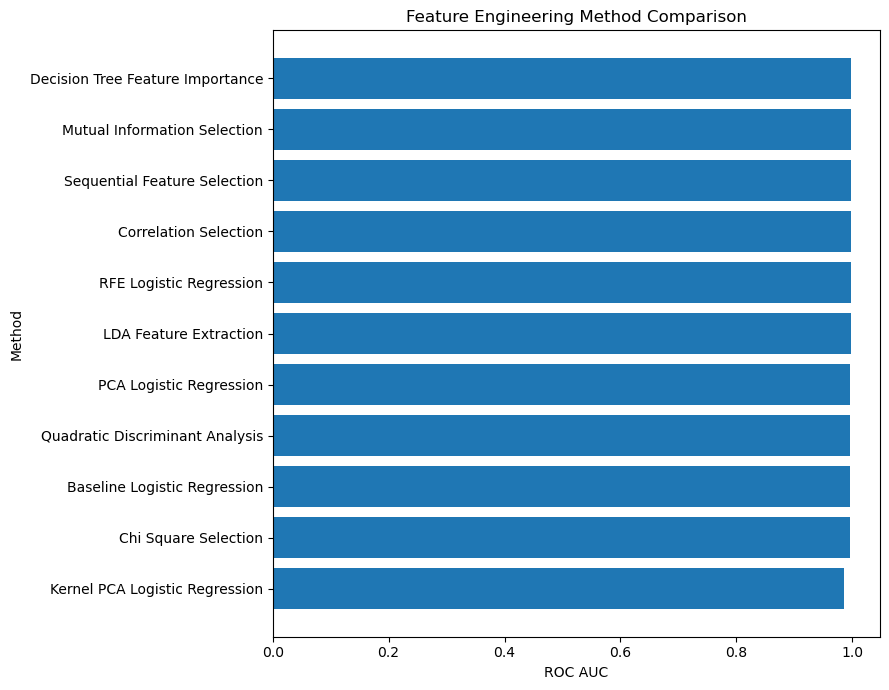

In [41]:
results_sorted = all_results.sort_values(by="ROC AUC", ascending=True)

plt.figure(figsize=(9, 7))

plt.barh(
    results_sorted["Model"],
    results_sorted["ROC AUC"]
)

plt.xlabel("ROC AUC")
plt.ylabel("Method")
plt.title("Feature Engineering Method Comparison")
plt.tight_layout()
plt.show()

### Print the best method

In [42]:
best_method = all_results.sort_values(
    by="ROC AUC",
    ascending=False
).iloc[0]

print("Best Feature Engineering Method")
print("-------------------------------")
print(f"Method: {best_method['Model']}")
print(f"ROC AUC: {best_method['ROC AUC']:.3f}")
print(f"F1 Score: {best_method['F1 Score']:.3f}")
print(f"Recall: {best_method['Recall']:.3f}")

Best Feature Engineering Method
-------------------------------
Method: Decision Tree Feature Importance
ROC AUC: 0.998
F1 Score: 0.951
Recall: 0.929
